# Procesamiento de Imágenes
## Sesión práctica 7 - DoG y SIFT
Profesor: Cristóbal Loyola<br>
Ayudante: Clemente Aguilar<br>
<br>Universidad de Santiago de Chile, 2025

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color
from skimage.exposure import rescale_intensity
from skimage.util import img_as_ubyte
from skimage.color import rgb2gray
from skimage import exposure
from skimage.io import imread
from skimage.filters import threshold_otsu
import cv2
import os

In [ ]:
# Ejemplo de tratamiento de imagen con más de 3 canales.
img = data.lily()
print(img.shape)
rgb_img = img[:, :, :3]
print(f"Valor mínimo: {np.min(rgb_img)}")
print(f"Valor máximo: {np.max(rgb_img)}")

rgb_scaled = (rgb_img / np.max(rgb_img)) * 255
rgb_uint8 = rgb_scaled.astype(np.uint8)

#show_image(rgb_uint8)

(922, 922, 4)
Valor mínimo: 0
Valor máximo: 4095


## Cargar la imagen de esta sesión
Para esta sesión se utilizará la imagen `rocket` desde Scikit-Image.<br>
Si lo deseas, se disponen bloques para que puedas cargar tu propia imagen independientemente del entorno de trabajo que utilices.

In [ ]:
# Imagen a utilizar en la sesión. Siéntanse en total libertad de cargar sus
# propias imágenes para esta experiencia utilizando imágenes públicas o
img = data.rocket()
print(img.shape)

# 1. Si estás trabajando en Google Colab y tienes tu imagen en Drive
"""
from google.colab import drive
drive.mount('/content/drive')

path = "ruta/a/tu/imagen.jpg"
img = imread(path)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

# 2. Si estás trabajando en un entorno local (no Google Colab o Jupyter Notebook)
"""
# Cargar imagen desde una ruta local
path = "ruta/a/tu/imagen.jpg"
img = imread(path)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

# 3. Si deseas trabajar sobre una imagen encontrada en la web
"""
url = "https://www.url/de/tu/imagen.jpg"
img = imread(url)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

gray_img = rgb2gray(img)

(427, 640, 3)


In [ ]:
def difference_of_gaussian(input_img, sigma1=1.0, sigma2=2.0):
    """
    Aplica Difference of Gaussians (DoG) a una imagen en escala de grises.

    Parámetros:
        input_img (ndarray): Imagen en escala de grises (uint8 o float32).
        sigma1 (float): Desviación estándar del primer Gaussian blur (más fina).
        sigma2 (float): Desviación estándar del segundo Gaussian blur (más gruesa).

    Retorna:
        dog (ndarray): Imagen filtrada DoG.
    """
    blur1 = cv2.GaussianBlur(input_img, (0, 0), sigmaX=sigma1)
    blur2 = cv2.GaussianBlur(input_img, (0, 0), sigmaX=sigma2)
    dog = blur1 - blur2

    return dog


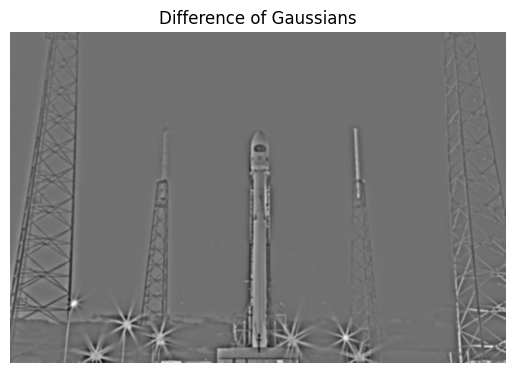

In [ ]:
dog_img = difference_of_gaussian(gray_img, 1.0, 4.0)

plt.imshow(dog_img, cmap='gray')
plt.title("Difference of Gaussians")
plt.axis('off')
plt.show()

In [ ]:
!pip install opencv-contrib-python

In [ ]:
def sift_matching(img1, img2, ratio_thresh=0.75, min_response=0.01, max_keypoints=None):
    """
    Extrae y compara keypoints entre dos imágenes usando SIFT, con filtro por robustez.

    Parámetros:
        img1, img2 (ndarray): Imágenes en escala de grises.
        ratio_thresh (float): Umbral de Lowe ratio test.
        min_response (float): Valor mínimo de respuesta para keypoints robustos.
        max_keypoints (int or None): Limita la cantidad de keypoints por imagen.

    Retorna:
        img_matches (ndarray): Imagen de coincidencias visuales.
        good_matches (list): Lista de coincidencias válidas.
        kp1, kp2 (list): Keypoints filtrados usados en el matching.
    """
    sift = cv2.SIFT_create()

    # Detectar todos los keypoints y descriptores
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    # Filtrar por respuesta mínima
    kp1_filtered = [kp for kp in kp1 if kp.response >= min_response]
    kp2_filtered = [kp for kp in kp2 if kp.response >= min_response]

    # Ordenar por respuesta y limitar si se desea
    if max_keypoints is not None:
        kp1_filtered = sorted(kp1_filtered, key=lambda k: -k.response)[:max_keypoints]
        kp2_filtered = sorted(kp2_filtered, key=lambda k: -k.response)[:max_keypoints]

    # Recalcular descriptores para los keypoints filtrados
    kp1_filtered, des1_filtered = sift.compute(img1, kp1_filtered)
    kp2_filtered, des2_filtered = sift.compute(img2, kp2_filtered)

    # FLANN matcher
    index_params = dict(algorithm=1, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1_filtered, des2_filtered, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)

    img_matches = cv2.drawMatches(
        img1, kp1_filtered, img2, kp2_filtered, good_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return img_matches, good_matches, kp1_filtered, kp2_filtered

In [ ]:
def plot_keypoints(img, keypoints, title="Keypoints"):
    """
    Dibuja los keypoints sobre la imagen usando OpenCV y matplotlib.

    Parámetros:
        img (ndarray): Imagen en escala de grises o color.
        keypoints (list): Lista de objetos cv2.KeyPoint.
        title (str): Título para la visualización.
    """
    img_kp = cv2.drawKeypoints(
        img, keypoints, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        color=(0, 255, 0)
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB) if img_kp.ndim == 3 else img_kp, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


img1_planetario.png  img2_planetario.png  img3_planetario.png  sample_data


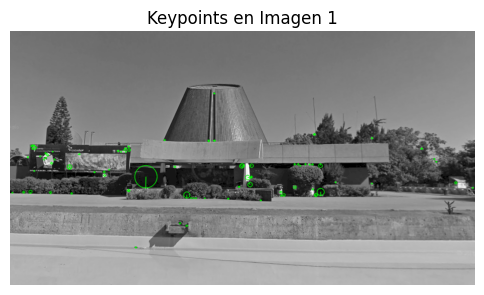

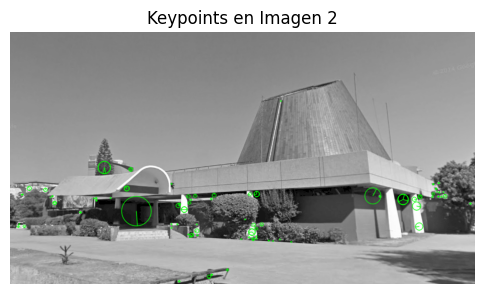

In [ ]:
!ls
img1 = cv2.imread("img1_planetario.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("img3_planetario.png", cv2.IMREAD_GRAYSCALE)

matches_img, matches, kp1, kp2 = sift_matching(
    img1, img2,
    ratio_thresh=0.75,
    min_response=0.03,
    max_keypoints=100
)

plot_keypoints(img1, kp1, title="Keypoints en Imagen 1")
plot_keypoints(img2, kp2, title="Keypoints en Imagen 2")